In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# **Collection Data**

In [13]:
# 1. Load the XAU/USD dataset
import os
data_path = "XAU_USD_Historical_Data.csv"
if not os.path.exists(data_path):
    data_path = "../data/raw/XAU_USD_Historical_Data.csv"
if not os.path.exists(data_path):
    data_path = "../../XAU_USD_Historical_Data.csv"

print(f"Loading XAU/USD data from {data_path}...")
df = pd.read_csv(data_path)
print(f"Data Loading Done. Total rows: {df.shape[0]}")

Loading XAU/USD data from ../data/raw/XAU_USD_Historical_Data.csv...
Data Loading Done. Total rows: 4346


# **Data Cleaning**

In [14]:
# Drop "Vol." column: Spot Gold (XAU/USD) trades on a decentralized OTC network
# with no centralized exchange feed, leading to 100% missing (NaN) values.
# Technical indicators (SMA, RSI, MACD, ATR) depend strictly on OHLC prices.
df.drop(columns=["Vol."], inplace=True, errors="ignore")

# (Fixing Investing.com specific quirks)
# A. Reverse Chronological Order (Investing.com puts newest data first, we need oldest first for ML)
df = df.iloc[::-1].reset_index(drop=True)

# B. Convert Data Types (Remove commas from strings and convert to numerical floats)
cols_to_clean = ["Price", "Open", "High", "Low"]
for col in cols_to_clean:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(",", "", regex=False).str.strip().astype(float)

# Rename "Price" to "Close" for standard financial analysis terminology
if "Price" in df.columns:
    df.rename(columns={"Price": "Close"}, inplace=True)

# Drop any rows with completely missing price data
df.dropna(subset=["Close", "High", "Low"], inplace=True)

print("Calculating Technical Indicators...")
# Moving Averages
df["SMA_14"] = df["Close"].rolling(window=14).mean()
df["SMA_50"] = df["Close"].rolling(window=50).mean()

# RSI (Relative Strength Index)
delta = df["Close"].diff()
gain = (delta.where(delta > 0, 0.0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0.0)).rolling(window=14).mean()
rs = gain / loss.replace(0, np.nan)
df["RSI_14"] = 100 - (100 / (1 + rs))
df["RSI_14"] = df["RSI_14"].fillna(50.0)

# MACD
ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
ema_26 = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"] = ema_12 - ema_26
df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

# ATR (Average True Range - Essential for Member 2's TP/SL logic)
high_low = df["High"] - df["Low"]
high_close = np.abs(df["High"] - df["Close"].shift())
low_close = np.abs(df["Low"] - df["Close"].shift())
ranges = pd.concat([high_low, high_close, low_close], axis=1)
true_range = np.max(ranges, axis=1)
df["ATR_14"] = true_range.rolling(14).mean()

# Target Variable (1 for UP trend, 0 for DOWN trend)
df["Target_Next_Close"] = df["Close"].shift(-1)
df["Target_Trend"] = np.where(df["Target_Next_Close"] > df["Close"], 1, 0)

# 4. Final Cleanup & Export
# Drop rows with NaN values created by the rolling windows (e.g., the first 50 days)
df_clean = df.dropna().copy()

# Save the final engineered dataset
output_file = "XAU_USD_Final_Engineered.csv"
df_clean.to_csv(output_file, index=False)

print(f"Duplicated rows: {df_clean.duplicated().sum()}")
print(f"Missing values:\n{df_clean.isnull().sum()}")
print("------------------------------")
print(f"Success! Engineered dataset saved to {output_file}")
print(f"Total Rows Ready for ML Training: {df_clean.shape[0]}")

Calculating Technical Indicators...
Duplicated rows: 0
Missing values:
Date                 0
Close                0
Open                 0
High                 0
Low                  0
Change %             0
SMA_14               0
SMA_50               0
RSI_14               0
MACD                 0
MACD_Signal          0
ATR_14               0
Target_Next_Close    0
Target_Trend         0
dtype: int64
------------------------------
Success! Engineered dataset saved to XAU_USD_Final_Engineered.csv
Total Rows Ready for ML Training: 4296


# **Data Visaling**

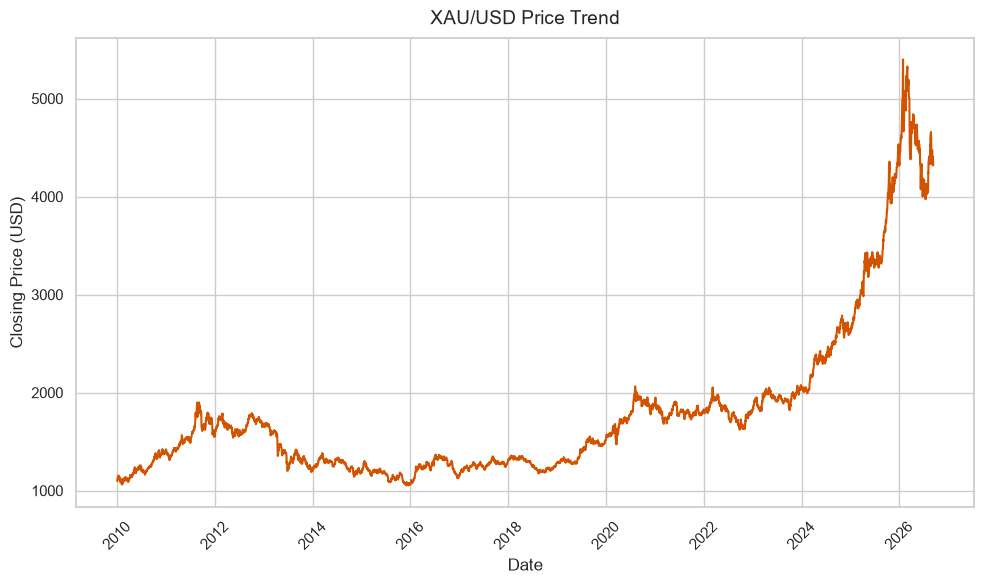

In [15]:
# 1. Set up the professional plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Define the X-axis
if 'Date' in df_clean.columns:
    x_axis = pd.to_datetime(df['Date'])
    xlabel = 'Date'
else:
    x_axis = df_clean.index
    xlabel = 'Trading Days (Sequential)'

# 3. Plot the Close Price Line Chart
plt.plot(x_axis, df['Close'], color='#d35400', linestyle='-', linewidth=1.5)

# 4. Format the chart elements
plt.title('XAU/USD Price Trend', fontsize=14, pad=10)
plt.xlabel(xlabel, fontsize=12)
plt.ylabel('Closing Price (USD)', fontsize=12)

# If using Dates, rotate the labels for readability
if xlabel == 'Date':
    plt.xticks(rotation=45)

plt.tight_layout()

# 5. Display or Save the chart
plt.show()

# **Feature Engineering**

In [16]:
# 1. Feature Creation
# Calculate additional market dynamics and volatility features.
# Moving Averages (SMA_14, SMA_50), RSI, MACD, and ATR were calculated in the previous step.
# Here, we add the daily price range to capture intraday volatility.
df_clean['Price_Range'] = df_clean['High'] - df_clean['Low']

#Create Stationary Features (Percentage Returns)
df_clean['Return_1d'] = df_clean['Close'].pct_change()
df_clean['Return_3d'] = df_clean['Close'].pct_change(periods=3)

#Create Lag Features (Yesterday's data)
df_clean['Close_Lag1'] = df_clean['Close'].shift(1)
df_clean['RSI_Lag1'] = df_clean['RSI_14'].shift(1)

df_clean.dropna(inplace=True)

features = [
    'Return_1d', 'Return_3d', 'Close_Lag1', 'RSI_Lag1',
    'SMA_14', 'SMA_50', 'RSI_14', 'MACD', 'MACD_Signal', 'ATR_14', 'Price_Range'
]

X = df_clean[features]
y = df_clean['Target_Trend']

# Ensure target variable is strictly formatted as binary integers (1 = UP / Bullish, 0 = DOWN / Bearish).
y = y.astype(int)

# **Split the Dataset**

In [17]:
# test_size=0.2 uses the oldest 80% for training and newest 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for inspection and export
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features)

print("=" * 50)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 50)
print(f"Total Selected Features : {len(features)}")
print(f"Features List           : {features}")
print(f"Training Samples (80%)  : {X_train_scaled.shape[0]}")
print(f"Testing Samples (20%)   : {X_test_scaled.shape[0]}")
print(f"Target Distribution     :\n{y.value_counts(normalize=True).round(4) * 100}")
print("\nFirst 3 rows of Scaled Training Data:")
display(X_train_scaled_df.head(3))

FEATURE ENGINEERING SUMMARY
Total Selected Features : 11
Features List           : ['Return_1d', 'Return_3d', 'Close_Lag1', 'RSI_Lag1', 'SMA_14', 'SMA_50', 'RSI_14', 'MACD', 'MACD_Signal', 'ATR_14', 'Price_Range']
Training Samples (80%)  : 3434
Testing Samples (20%)   : 859
Target Distribution     :
Target_Trend
1    52.67
0    47.33
Name: proportion, dtype: float64

First 3 rows of Scaled Training Data:


,Return_1d,Return_3d,Close_Lag1,RSI_Lag1,SMA_14,SMA_50,RSI_14,MACD,MACD_Signal,ATR_14,Price_Range
0,0.148782,-0.312790,-0.611933,-0.925972,-0.614985,-0.605059,-0.902020,-0.281852,-0.274646,-0.593042,-0.592470
1,0.094996,-1.093033,-0.625033,-0.395306,-0.605739,-0.600784,-0.216756,-0.233910,-0.204099,-0.569891,-0.457462
2,0.258237,1.668090,-0.234044,0.499543,-0.277504,-0.244272,0.685484,-0.033272,-0.248145,0.886800,-0.255542


# **Model Selection**

In [18]:
print("Select Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

print("Select Support Vector Classifier (SVC)...")
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42
)

Select Random Forest Classifier...
Select Support Vector Classifier (SVC)...


# **Training**

In [19]:
print("Training Random Forest Classifier...")
rf_model.fit(X_train, y_train)

print("Training Support Vector Classifier (SVC)...")
svm_model.fit(X_train_scaled, y_train)

Training Random Forest Classifier...
Training Support Vector Classifier (SVC)...


C:\Users\Lahiru Mudith\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200


# **Prediction**

In [20]:
# Predictions on unseen test data
rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds, zero_division=0)
rf_recall = recall_score(y_test, rf_preds, zero_division=0)
rf_f1 = f1_score(y_test, rf_preds, zero_division=0)

# Predictions on scaled test data
svm_preds = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_preds)
svm_precision = precision_score(y_test, svm_preds, zero_division=0)
svm_recall = recall_score(y_test, svm_preds, zero_division=0)
svm_f1 = f1_score(y_test, svm_preds, zero_division=0)

# **Model Comparison Table**

In [21]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Random Forest': [rf_acc, rf_precision, rf_recall, rf_f1],
    'SVM (RBF)': [svm_acc, svm_precision, svm_recall, svm_f1]
})

print("\n" + "=" * 50)
print("MODEL EVALUATION & COMPARISON")
print("=" * 50)
display(comparison_df.round(4))

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, rf_preds, target_names=['DOWN (0)', 'UP (1)']))

print("\nClassification Report (SVM):")
print(classification_report(y_test, svm_preds, target_names=['DOWN (0)', 'UP (1)']))


MODEL EVALUATION & COMPARISON


,Metric,Random Forest,SVM (RBF)
0,Accuracy,0.4726,0.4866
1,Precision,0.4821,0.4963
2,Recall,0.4612,0.4635
3,F1-Score,0.4714,0.4793



Classification Report (Random Forest):
              precision    recall  f1-score   support

    DOWN (0)       0.46      0.48      0.47       421
      UP (1)       0.48      0.46      0.47       438

    accuracy                           0.47       859
   macro avg       0.47      0.47      0.47       859
weighted avg       0.47      0.47      0.47       859


Classification Report (SVM):
              precision    recall  f1-score   support

    DOWN (0)       0.48      0.51      0.49       421
      UP (1)       0.50      0.46      0.48       438

    accuracy                           0.49       859
   macro avg       0.49      0.49      0.49       859
weighted avg       0.49      0.49      0.49       859



# **Model Selection and Artifact Serialization**

In [22]:
if rf_acc >= svm_acc:
    selected_model = rf_model
    model_name = "RandomForest"
    needs_scaler = False
else:
    selected_model = svm_model
    model_name = "SVM"
    needs_scaler = True

print("=" * 50)
print(f"Selected Model: {model_name} (Highest Test Accuracy: {max(rf_acc, svm_acc) * 100:.2f}%)")
print("=" * 50)

# Save the trained model and feature scaler
joblib.dump(selected_model, 'gold_trend_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Exported artifacts:")
print("- 'gold_trend_model.pkl' (Trained ML model)")
print("- 'scaler.pkl' (StandardScaler for API inference)")

Selected Model: SVM (Highest Test Accuracy: 48.66%)
Exported artifacts:
- 'gold_trend_model.pkl' (Trained ML model)
- 'scaler.pkl' (StandardScaler for API inference)
